In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import streamlit as st
import holidays

# Cargar los datos de ventas
df_ventas = pd.read_csv("../data/raw/entrenamiento/ventas.csv")

# Cargar los datos de competencias
df_competencias = pd.read_csv("../data/raw/entrenamiento/competencia.csv")

In [62]:
# Validación de la calidad de datos de df_ventasdf_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])
# Tipos de variables
print('Tipos de variables:')
print(df_ventas.dtypes)
print('\n')

# Valores nulos
print('Valores nulos por columna:')
print(df_ventas.isnull().sum())
print('\n')

# Duplicados
print('Cantidad de filas duplicadas:')
print(df_ventas.duplicated().sum())
print('\n')

# Estadísticas descriptivas
print('Estadísticas descriptivas:')
print(df_ventas.describe(include='all'))
print('\n')

# Resumen final de calidad de datos
def informe_calidad(df):
    print('--- INFORME DE CALIDAD DE DATOS ---')
    print(f'Filas totales: {df.shape[0]}')
    print(f'Columnas totales: {df.shape[1]}')
    print('Columnas con nulos:', df.columns[df.isnull().any()].tolist())
    print('Tipos de datos:')
    print(df.dtypes)
    print('-------------------------------------')

informe_calidad(df_ventas)

Tipos de variables:
fecha                 object
producto_id           object
nombre                object
categoria             object
subcategoria          object
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object


Valores nulos por columna:
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64


Cantidad de filas duplicadas:
0


Estadísticas descriptivas:
             fecha producto_id                    nombre categoria  \
count         3552        3552                      3552      3552   
unique         148          24                        24         4   
top     2021-10-25    PROD_001  Nike Air Zoom Pegasus 40   Running   
freq            24         148                       148     

In [63]:
# Validación de la calidad de datos de df_competencias
# Tipos de variables
print('Tipos de variables:')
print(df_competencias.dtypes)
print('\n')

# Valores nulos
print('Valores nulos por columna:')
print(df_competencias.isnull().sum())
print('\n')

# Duplicados
print('Cantidad de filas duplicadas:')
print(df_competencias.duplicated().sum())
print('\n')

# Estadísticas descriptivas
print('Estadísticas descriptivas:')
print(df_competencias.describe(include='all'))
print('\n')

# Resumen final de calidad de datos
def informe_calidad(df):
    print('--- INFORME DE CALIDAD DE DATOS ---')
    print(f'Filas totales: {df.shape[0]}')
    print(f'Columnas totales: {df.shape[1]}')
    print('Columnas con nulos:', df.columns[df.isnull().any()].tolist())
    print('Tipos de datos:')
    print(df.dtypes)
    print('-------------------------------------')

informe_calidad(df_competencias)

Tipos de variables:
fecha            object
producto_id      object
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object


Valores nulos por columna:
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64


Cantidad de filas duplicadas:
0


Estadísticas descriptivas:
             fecha producto_id       Amazon    Decathlon  Deporvillage
count         3552        3552  3552.000000  3552.000000   3552.000000
unique         148          24          NaN          NaN           NaN
top     2021-10-25    PROD_001          NaN          NaN           NaN
freq            24         148          NaN          NaN           NaN
mean           NaN         NaN   118.623407   111.412182    118.894628
std            NaN         NaN   156.095628   148.508132    160.216448
min            NaN         NaN    16.850000    15.450000     16.770000
25%            NaN         NaN    47.117500    43.285000     47.310000
50%         

In [64]:
df_competencias['fecha'] = pd.to_datetime(df_competencias['fecha'])
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])

In [65]:
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 253.3+ KB


In [66]:
df_competencias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[ns]
 1   producto_id   3552 non-null   object        
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 138.9+ KB


In [67]:
# Integración de los datos de ventas y competencia en un solo DataFrame
# Usando 'fecha' y 'producto_id' como claves

df = pd.merge(df_ventas, df_competencias, on=["fecha", "producto_id"], how="inner")

df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


## Análisis exploratorio de DF
En las siguientes celdas se realiza un análisis exploratorio completo del DataFrame `df` integrando ventas y competencia. Se incluyen gráficos temporales, por categorías, subcategorías, productos top y análisis de precios propios y de Amazon.

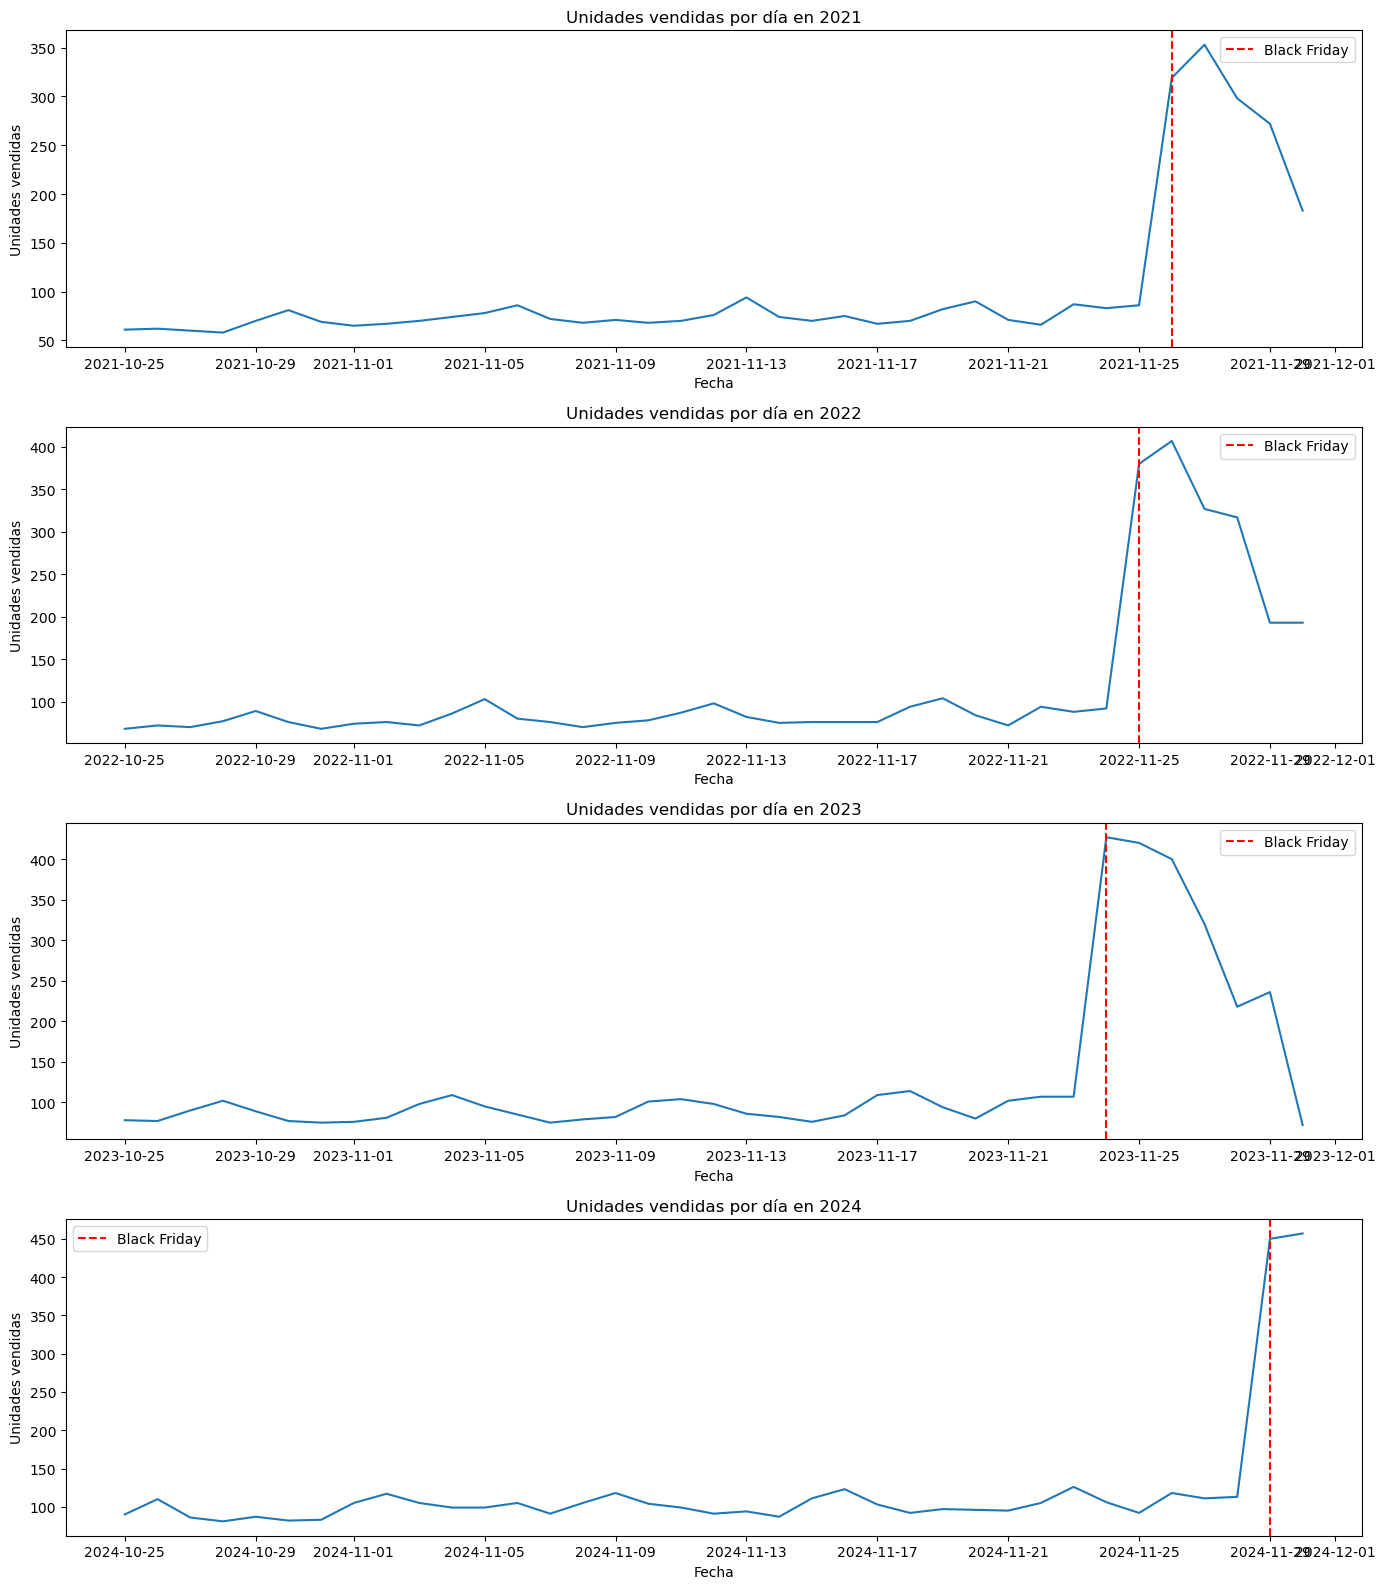

In [68]:


# Aseguramos que la columna fecha es datetime
ventas_df = df.copy()
ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'])
ventas_df['año'] = ventas_df['fecha'].dt.year

# Identificar Black Fridays (último viernes de noviembre de cada año)
def get_black_fridays(years):
    bfs = []
    for y in years:
        nov = pd.date_range(start=f'{y}-11-01', end=f'{y}-11-30', freq='D')
        fridays = nov[nov.weekday == 4]
        bfs.append(fridays[-1])
    return bfs

years = ventas_df['año'].unique()
black_fridays = get_black_fridays(years)

fig, axes = plt.subplots(len(years), 1, figsize=(14, 4*len(years)), sharex=False)
if len(years) == 1:
    axes = [axes]
for i, y in enumerate(sorted(years)):
    data = ventas_df[ventas_df['año'] == y].groupby('fecha')['unidades_vendidas'].sum().reset_index()
    sns.lineplot(data=data, x='fecha', y='unidades_vendidas', ax=axes[i])
    axes[i].set_title(f'Unidades vendidas por día en {y}')
    axes[i].set_ylabel('Unidades vendidas')
    axes[i].set_xlabel('Fecha')
    # Marcar Black Friday
    bf = [d for d in black_fridays if d.year == y][0]
    axes[i].axvline(bf, color='red', linestyle='--', label='Black Friday')
    axes[i].legend()
plt.tight_layout()
plt.show()

### Suma de unidades vendidas por día de la semana
A continuación, se muestra un gráfico de la suma de unidades vendidas agregadas por cada día de la semana.

C:\Users\alexa\AppData\Local\Temp\ipykernel_25944\2525543277.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_dia.index, y=df_dia.values, palette='viridis')


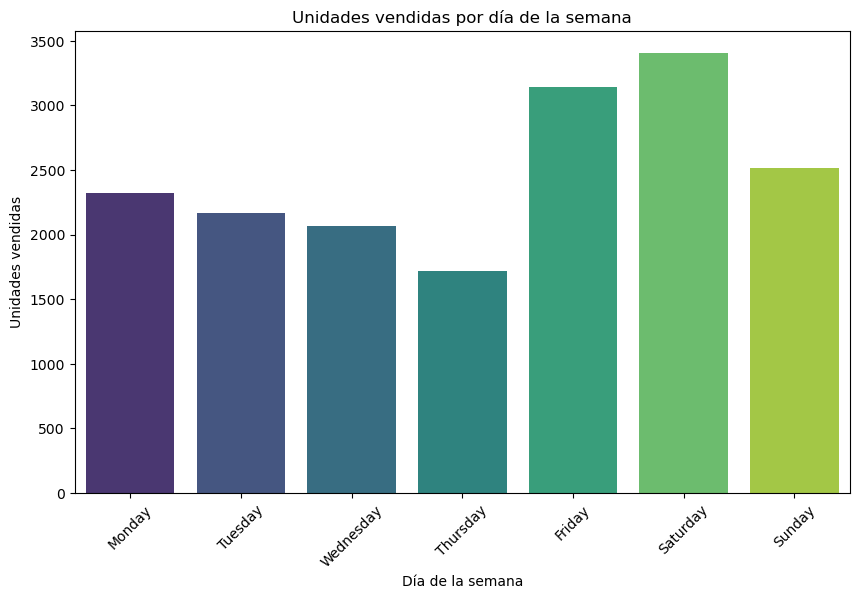

In [69]:
# Suma de unidades vendidas por día de la semana
ventas_df['dia_semana'] = ventas_df['fecha'].dt.day_name()
df_dia = ventas_df.groupby('dia_semana')['unidades_vendidas'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.figure(figsize=(10,6))
sns.barplot(x=df_dia.index, y=df_dia.values, palette='viridis')
plt.title('Unidades vendidas por día de la semana')
plt.ylabel('Unidades vendidas')
plt.xlabel('Día de la semana')
plt.xticks(rotation=45)
plt.show()

### Suma de unidades vendidas por categoría
A continuación, se muestra un gráfico de la suma de unidades vendidas por cada categoría de producto.

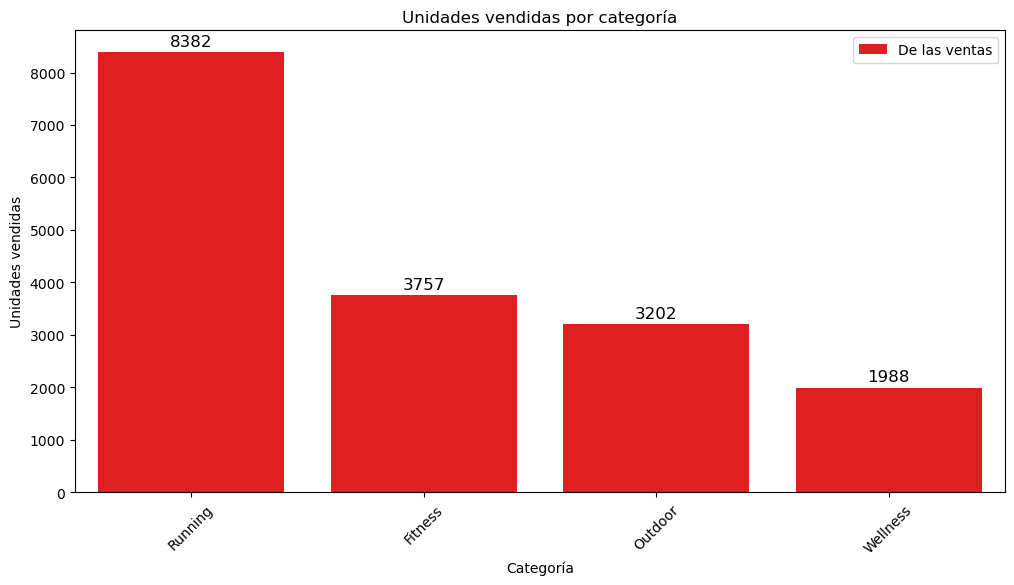

In [70]:
# Suma de unidades vendidas por categoría
plt.figure(figsize=(12,6))
categoria_sum = ventas_df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False)
bars = sns.barplot(x=categoria_sum.index, y=categoria_sum.values, color='red', label='De las ventas')
plt.title('Unidades vendidas por categoría')
plt.ylabel('Unidades vendidas')
plt.xlabel('Categoría')
plt.xticks(rotation=45)
plt.legend()
for bar in bars.patches:
    bars.annotate(format(bar.get_height(), '.0f'), 
                   (bar.get_x() + bar.get_width() / 2, 
                    bar.get_height()), ha='center', va='center',
                   size=12, xytext=(0, 8),
                   textcoords='offset points')
plt.show()

### Suma de unidades vendidas por subcategoría
A continuación, se muestra un gráfico de la suma de unidades vendidas por cada subcategoría de producto.

C:\Users\alexa\AppData\Local\Temp\ipykernel_25944\588866669.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_sum.index, y=subcat_sum.values, palette='mako')


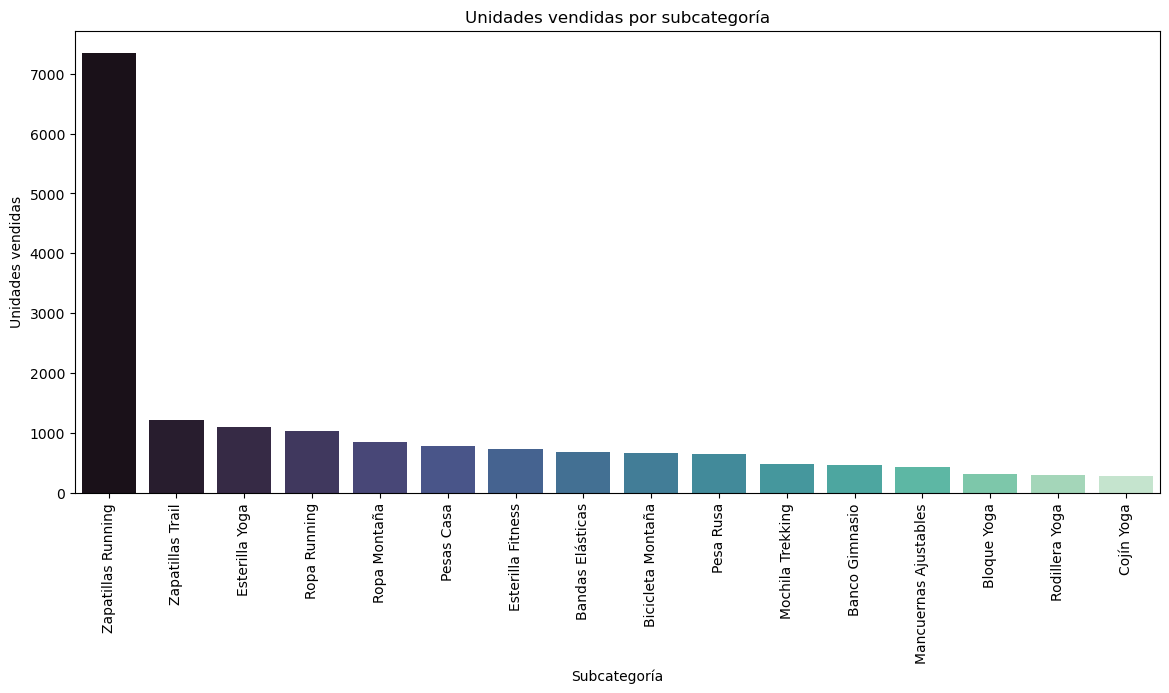

In [71]:
# Suma de unidades vendidas por subcategoría
plt.figure(figsize=(14,6))
subcat_sum = ventas_df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False)
sns.barplot(x=subcat_sum.index, y=subcat_sum.values, palette='mako')
plt.title('Unidades vendidas por subcategoría')
plt.ylabel('Unidades vendidas')
plt.xlabel('Subcategoría')
plt.xticks(rotation=90)
plt.show()

### Suma de unidades vendidas por los productos top
A continuación, se muestra un gráfico de los productos con mayor cantidad de unidades vendidas (top 10).

C:\Users\alexa\AppData\Local\Temp\ipykernel_25944\2045687841.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_productos.index.get_level_values(1), x=top_productos.values, palette='rocket')


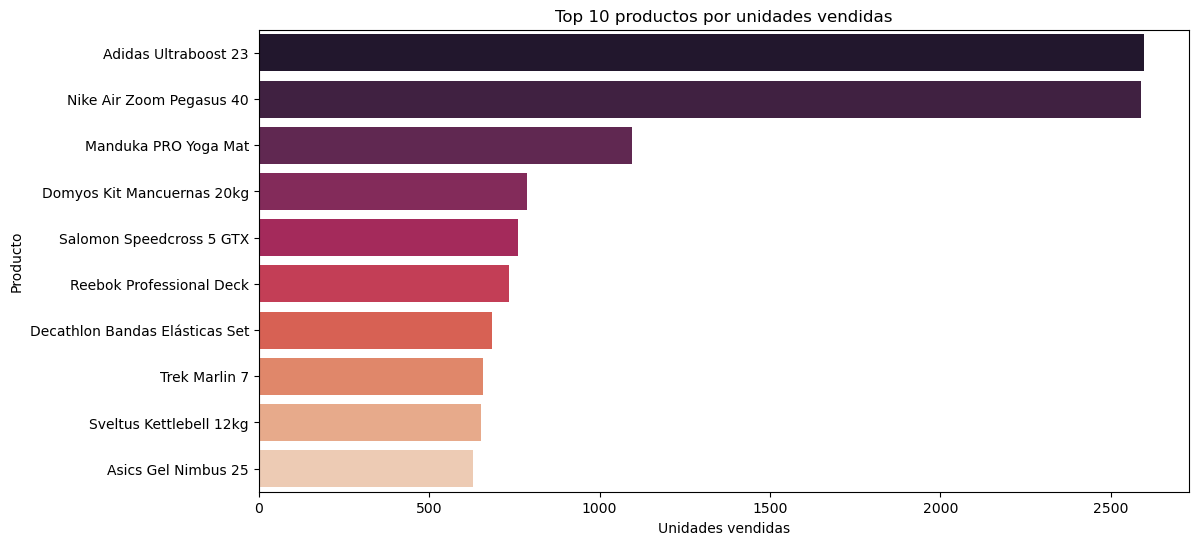

In [72]:
# Top 10 productos por unidades vendidas
top_productos = ventas_df.groupby(['producto_id', 'nombre'])['unidades_vendidas'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(y=top_productos.index.get_level_values(1), x=top_productos.values, palette='rocket')
plt.title('Top 10 productos por unidades vendidas')
plt.xlabel('Unidades vendidas')
plt.ylabel('Producto')
plt.show()

### Análisis de la densidad de distribución de precios
A continuación, se muestra un gráfico de densidad comparando la distribución de los precios de venta propios y los precios de Amazon como referencia de la competencia.

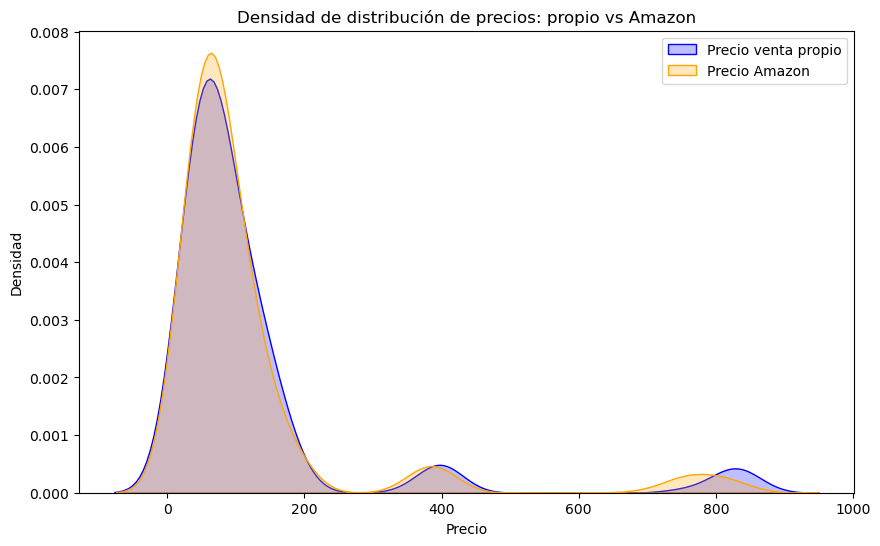

In [73]:
# Análisis de la densidad de distribución de precios propios y de Amazon
plt.figure(figsize=(10,6))
sns.kdeplot(ventas_df['precio_venta'], label='Precio venta propio', fill=True, color='blue')
sns.kdeplot(ventas_df['Amazon'], label='Precio Amazon', fill=True, color='orange')
plt.title('Densidad de distribución de precios: propio vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.show()

In [74]:
# Creación de variables temporales y de calendario en ventas_df

import holidays

# Variables básicas de fecha
ventas_df['año'] = ventas_df['fecha'].dt.year
ventas_df['mes'] = ventas_df['fecha'].dt.month
ventas_df['dia_mes'] = ventas_df['fecha'].dt.day
ventas_df['dia_semana'] = ventas_df['fecha'].dt.dayofweek  # 0=Lunes, 6=Domingo
ventas_df['nombre_dia'] = ventas_df['fecha'].dt.day_name()
ventas_df['semana_año'] = ventas_df['fecha'].dt.isocalendar().week

# Es fin de semana
ventas_df['es_fin_semana'] = ventas_df['dia_semana'].isin([5, 6]).astype(int)

# Festivos en España
festivos = holidays.country_holidays('ES', years=ventas_df['año'].unique())
ventas_df['es_festivo'] = ventas_df['fecha'].isin(festivos).astype(int)

# Black Friday (último viernes de noviembre)
def es_black_friday(fecha):
    año = fecha.year
    nov = pd.date_range(start=f'{año}-11-01', end=f'{año}-11-30', freq='D')
    fridays = nov[nov.weekday == 4]
    return fecha == fridays[-1]

ventas_df['es_BlackFriday'] = ventas_df['fecha'].apply(es_black_friday).astype(int)

# Cyber Monday (primer lunes después de Black Friday)
def es_cyber_monday(fecha):
    año = fecha.year
    nov = pd.date_range(start=f'{año}-11-01', end=f'{año}-11-30', freq='D')
    fridays = nov[nov.weekday == 4]
    bf = fridays[-1]
    cm = bf + pd.Timedelta(days=(7 - bf.weekday()))
    return fecha == cm

ventas_df['es_CyberMonday'] = ventas_df['fecha'].apply(es_cyber_monday).astype(int)

# Variable: es_primer_dia_mes
ventas_df['es_primer_dia_mes'] = (ventas_df['dia_mes'] == 1).astype(int)

# Variable: es_ultimo_dia_mes
ventas_df['es_ultimo_dia_mes'] = (ventas_df['fecha'] == ventas_df['fecha'] + pd.offsets.MonthEnd(0)).astype(int)

# Variable: trimestre
ventas_df['trimestre'] = ventas_df['fecha'].dt.quarter

# Variable: mitad_mes (1=primera quincena, 2=segunda quincena)
ventas_df['mitad_mes'] = np.where(ventas_df['dia_mes'] <= 15, 1, 2)

# Variable: es_inicio_semana (lunes)
ventas_df['es_inicio_semana'] = (ventas_df['dia_semana'] == 0).astype(int)

# Variable: es_fin_semana (domingo)
ventas_df['es_fin_semana_dia'] = (ventas_df['dia_semana'] == 6).astype(int)

# Variable: es_laborable (no festivo y no fin de semana)
ventas_df['es_laborable'] = ((ventas_df['es_festivo'] == 0) & (ventas_df['es_fin_semana'] == 0)).astype(int)

# Mostrar las primeras filas con las nuevas variables
ventas_df.head()

C:\Users\alexa\AppData\Local\Temp\ipykernel_25944\3507677494.py:18: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  ventas_df['es_festivo'] = ventas_df['fecha'].isin(festivos).astype(int)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_festivo,es_BlackFriday,es_CyberMonday,es_primer_dia_mes,es_ultimo_dia_mes,trimestre,mitad_mes,es_inicio_semana,es_fin_semana_dia,es_laborable
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,0,0,0,0,0,4,2,1,0,1
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,0,0,0,0,0,4,2,1,0,1
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,0,0,0,0,0,4,2,1,0,1
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,0,0,0,0,0,4,2,1,0,1
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,0,0,0,0,0,4,2,1,0,1


In [75]:
# Crear lags de unidades vendidas y media móvil de 7 días por año

ventas_lags = []

for año in ventas_df['año'].unique():
    temp = ventas_df[ventas_df['año'] == año].sort_values('fecha').copy()
    # Crear lags de 1 a 7 días
    for lag in range(1, 8):
        temp[f'unidades_vendidas_lag{lag}'] = temp['unidades_vendidas'].shift(lag)
    # Media móvil de 7 días
    temp['unidades_vendidas_mm7'] = temp['unidades_vendidas'].rolling(window=7, min_periods=7).mean()
    ventas_lags.append(temp)

ventas_df = pd.concat(ventas_lags).sort_values(['año', 'fecha']).reset_index(drop=True)

# Eliminar registros con nulos en las nuevas variables
cols_lags = [f'unidades_vendidas_lag{lag}' for lag in range(1, 8)] + ['unidades_vendidas_mm7']
ventas_df = ventas_df.dropna(subset=cols_lags).reset_index(drop=True)

ventas_df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_fin_semana_dia,es_laborable,unidades_vendidas_lag1,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_mm7
0,2021-10-25,PROD_017,The North Face Borealis,Outdoor,Mochila Trekking,95,False,1,96.56,96.56,...,0,1,1.0,2.0,5.0,1.0,1.0,1.0,6.0,1.714286
1,2021-10-25,PROD_016,Trek Marlin 7,Outdoor,Bicicleta Montaña,830,True,2,821.29,1642.58,...,0,1,1.0,1.0,2.0,5.0,1.0,1.0,1.0,1.857143
2,2021-10-25,PROD_015,Salomon Speedcross 5 GTX,Outdoor,Zapatillas Trail,150,True,3,154.22,462.66,...,0,1,2.0,1.0,1.0,2.0,5.0,1.0,1.0,2.142857
3,2021-10-25,PROD_014,Sveltus Kettlebell 12kg,Fitness,Pesa Rusa,40,False,2,39.74,79.48,...,0,1,3.0,2.0,1.0,1.0,2.0,5.0,1.0,2.285714
4,2021-10-25,PROD_013,Decathlon Bandas Elásticas Set,Fitness,Bandas Elásticas,25,False,2,24.79,49.58,...,0,1,2.0,3.0,2.0,1.0,1.0,2.0,5.0,1.857143


In [76]:
# Variable de descuento Montaje (%)
ventas_df['descuento_porcentaje'] = ((ventas_df['precio_venta'] - ventas_df['precio_base']) / ventas_df['precio_base'] * 100)
ventas_df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_laborable,unidades_vendidas_lag1,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_mm7,descuento_porcentaje
0,2021-10-25,PROD_017,The North Face Borealis,Outdoor,Mochila Trekking,95,False,1,96.56,96.56,...,1,1.0,2.0,5.0,1.0,1.0,1.0,6.0,1.714286,1.642105
1,2021-10-25,PROD_016,Trek Marlin 7,Outdoor,Bicicleta Montaña,830,True,2,821.29,1642.58,...,1,1.0,1.0,2.0,5.0,1.0,1.0,1.0,1.857143,-1.049398
2,2021-10-25,PROD_015,Salomon Speedcross 5 GTX,Outdoor,Zapatillas Trail,150,True,3,154.22,462.66,...,1,2.0,1.0,1.0,2.0,5.0,1.0,1.0,2.142857,2.813333
3,2021-10-25,PROD_014,Sveltus Kettlebell 12kg,Fitness,Pesa Rusa,40,False,2,39.74,79.48,...,1,3.0,2.0,1.0,1.0,2.0,5.0,1.0,2.285714,-0.650000
4,2021-10-25,PROD_013,Decathlon Bandas Elásticas Set,Fitness,Bandas Elásticas,25,False,2,24.79,49.58,...,1,2.0,3.0,2.0,1.0,1.0,2.0,5.0,1.857143,-0.840000


In [77]:
# Calcular el precio promedio de la competencia
ventas_df['precio_competencia'] = ventas_df[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)

# Calcular el ratio de nuestro precio respecto a la competencia
ventas_df['ratio_precio'] = ventas_df['precio_venta'] / ventas_df['precio_competencia']

# Eliminar las columnas de los competidores
ventas_df = ventas_df.drop(columns=['Amazon', 'Decathlon', 'Deporvillage'])

ventas_df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_mm7,descuento_porcentaje,precio_competencia,ratio_precio
0,2021-10-25,PROD_017,The North Face Borealis,Outdoor,Mochila Trekking,95,False,1,96.56,96.56,...,2.0,5.0,1.0,1.0,1.0,6.0,1.714286,1.642105,92.636667,1.042352
1,2021-10-25,PROD_016,Trek Marlin 7,Outdoor,Bicicleta Montaña,830,True,2,821.29,1642.58,...,1.0,2.0,5.0,1.0,1.0,1.0,1.857143,-1.049398,735.070000,1.117295
2,2021-10-25,PROD_015,Salomon Speedcross 5 GTX,Outdoor,Zapatillas Trail,150,True,3,154.22,462.66,...,1.0,1.0,2.0,5.0,1.0,1.0,2.142857,2.813333,135.673333,1.136701
3,2021-10-25,PROD_014,Sveltus Kettlebell 12kg,Fitness,Pesa Rusa,40,False,2,39.74,79.48,...,2.0,1.0,1.0,2.0,5.0,1.0,2.285714,-0.650000,39.460000,1.007096
4,2021-10-25,PROD_013,Decathlon Bandas Elásticas Set,Fitness,Bandas Elásticas,25,False,2,24.79,49.58,...,3.0,2.0,1.0,1.0,2.0,5.0,1.857143,-0.840000,24.096667,1.028773


In [78]:
# Crear copias de las variables con sufijo _h
ventas_df['nombre_h'] = ventas_df['nombre']
ventas_df['categoria_h'] = ventas_df['categoria']
ventas_df['subcategoria_h'] = ventas_df['subcategoria']

# One Hot Encoding sobre las nuevas variables
ventas_df = pd.get_dummies(ventas_df, columns=['nombre_h', 'categoria_h', 'subcategoria_h'], prefix=['nombre_h', 'categoria_h', 'subcategoria_h'])

ventas_df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-10-25,PROD_017,The North Face Borealis,Outdoor,Mochila Trekking,95,False,1,96.56,96.56,...,False,False,True,False,False,False,False,False,False,False
1,2021-10-25,PROD_016,Trek Marlin 7,Outdoor,Bicicleta Montaña,830,True,2,821.29,1642.58,...,False,False,False,False,False,False,False,False,False,False
2,2021-10-25,PROD_015,Salomon Speedcross 5 GTX,Outdoor,Zapatillas Trail,150,True,3,154.22,462.66,...,False,False,False,False,False,False,False,False,False,True
3,2021-10-25,PROD_014,Sveltus Kettlebell 12kg,Fitness,Pesa Rusa,40,False,2,39.74,79.48,...,False,False,False,True,False,False,False,False,False,False
4,2021-10-25,PROD_013,Decathlon Bandas Elásticas Set,Fitness,Bandas Elásticas,25,False,2,24.79,49.58,...,False,False,False,False,False,False,False,False,False,False


In [79]:
ventas_df.to_csv('../data/processed/df.csv', index=False)

In [80]:
# División en train y validation
train_df = ventas_df[ventas_df['año'].isin([2021, 2022, 2023])].copy()
validation_df = ventas_df[ventas_df['año'] == 2024].copy()

print(f"Registros en train_df: {len(train_df)}")
print(f"Registros en validation_df: {len(validation_df)}")

Registros en train_df: 2643
Registros en validation_df: 881


In [81]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Selección de variables predictoras
excluir = ['fecha', 'ingresos', 'unidades_vendidas']
X_cols = [col for col in train_df.columns if col not in excluir and train_df[col].dtype != 'O']

X_train = train_df[X_cols]
y_train = train_df['unidades_vendidas']
X_val = validation_df[X_cols]
y_val = validation_df['unidades_vendidas']

# Modelo con parámetros conservadores
hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    early_stopping=True,
    random_state=42
)
hgb.fit(X_train, y_train)
y_pred = hgb.predict(X_val)

# Baseline naive: predice la media del train
y_pred_naive = np.full_like(y_val, y_train.mean(), dtype=float)

# Métricas
def print_metrics(y_true, y_pred, nombre):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre}:")
    print(f"  MAE:  {mae:.2f}")
    print(f"  MSE:  {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2:   {r2:.3f}\n")

print_metrics(y_val, y_pred, "HistGradientBoostingRegressor")
print_metrics(y_val, y_pred_naive, "Baseline Naive (media)")

HistGradientBoostingRegressor:
  MAE:  0.92
  MSE:  3.88
  RMSE: 1.97
  R2:   0.901

Baseline Naive (media):
  MAE:  3.35
  MSE:  39.17
  RMSE: 6.26
  R2:   -0.001



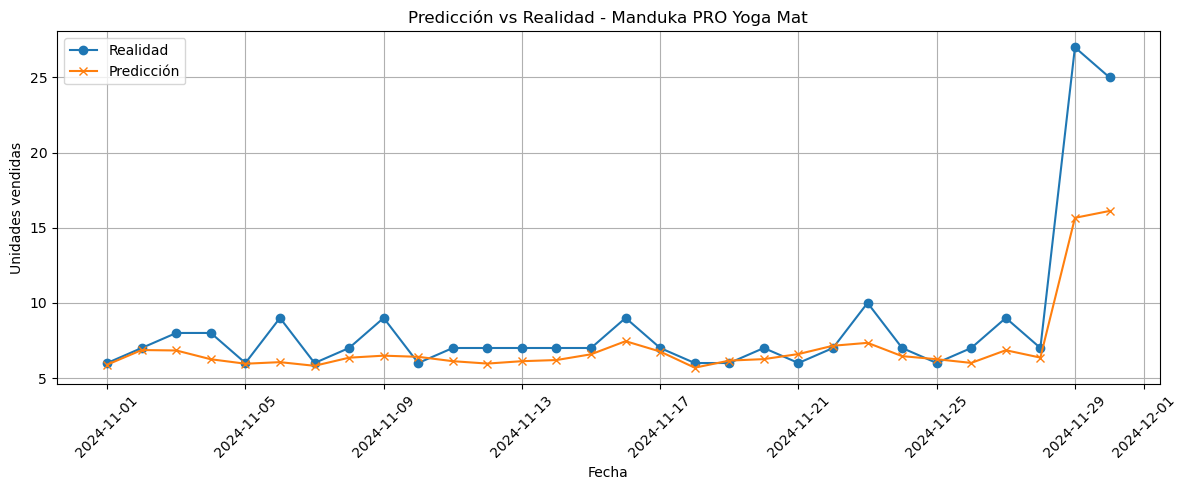

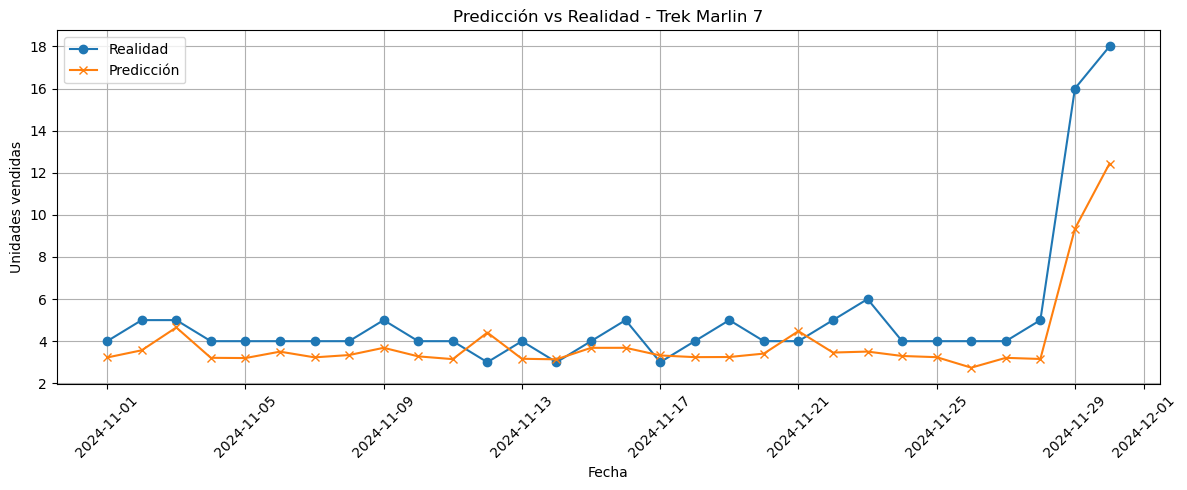

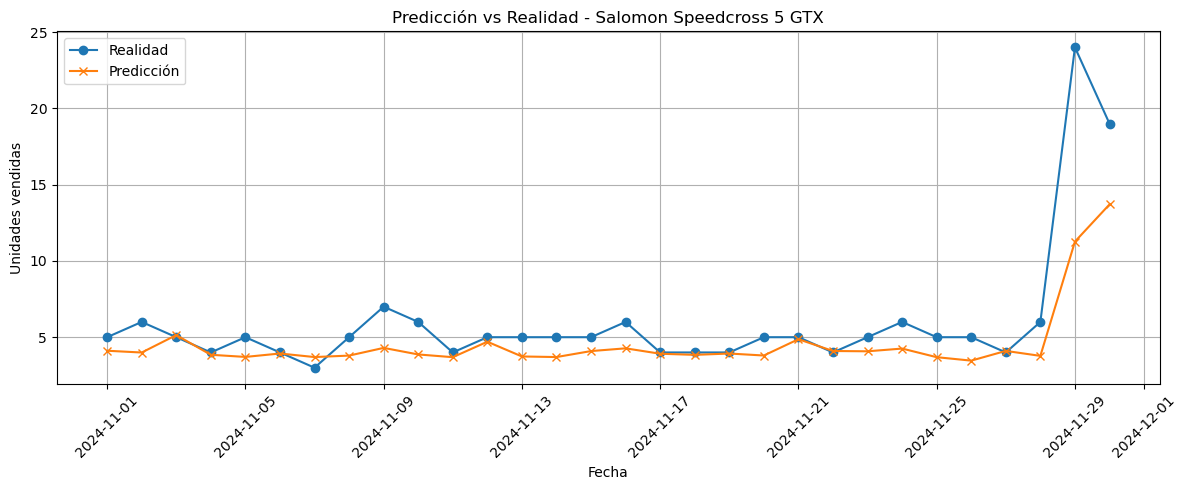

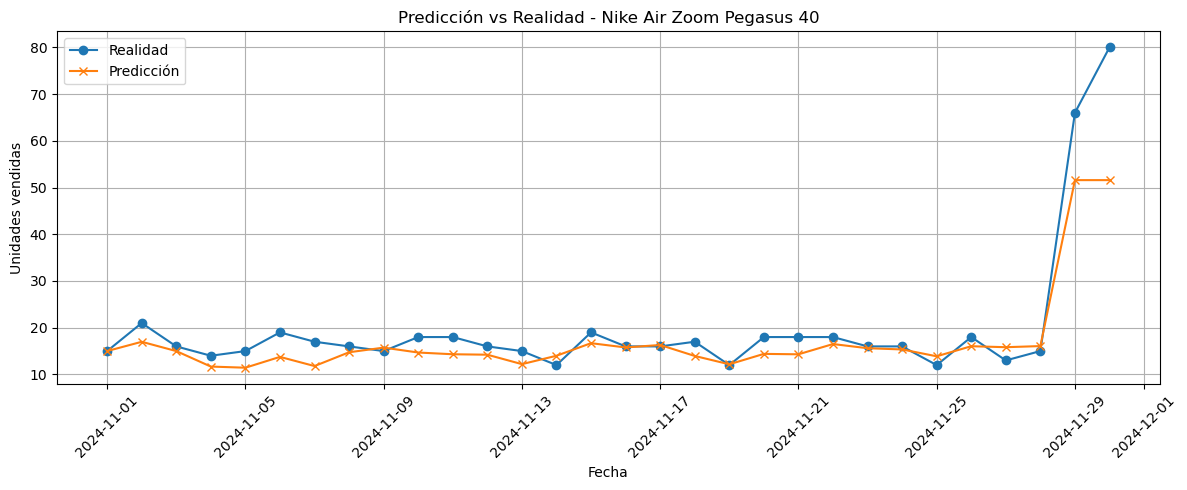

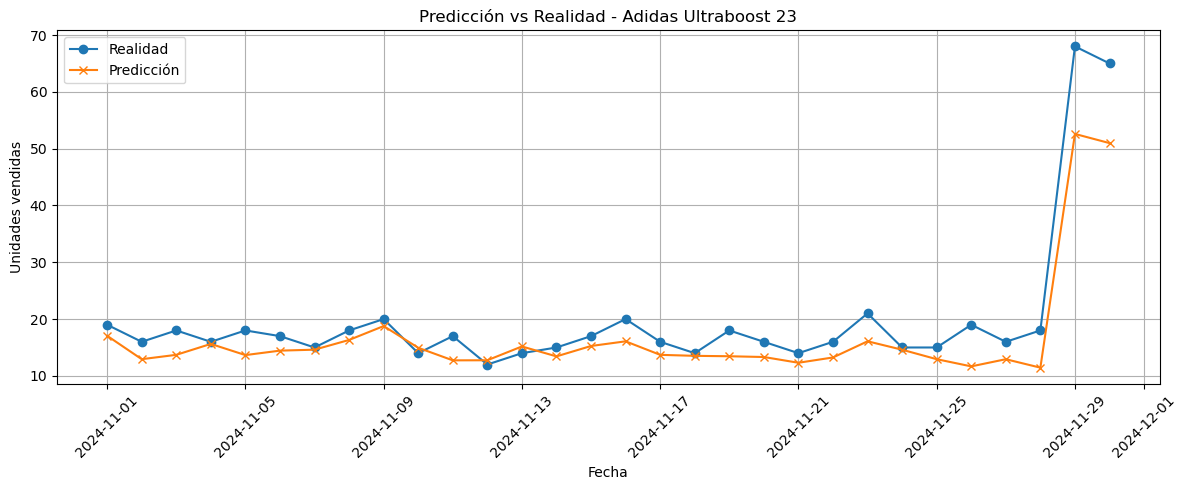

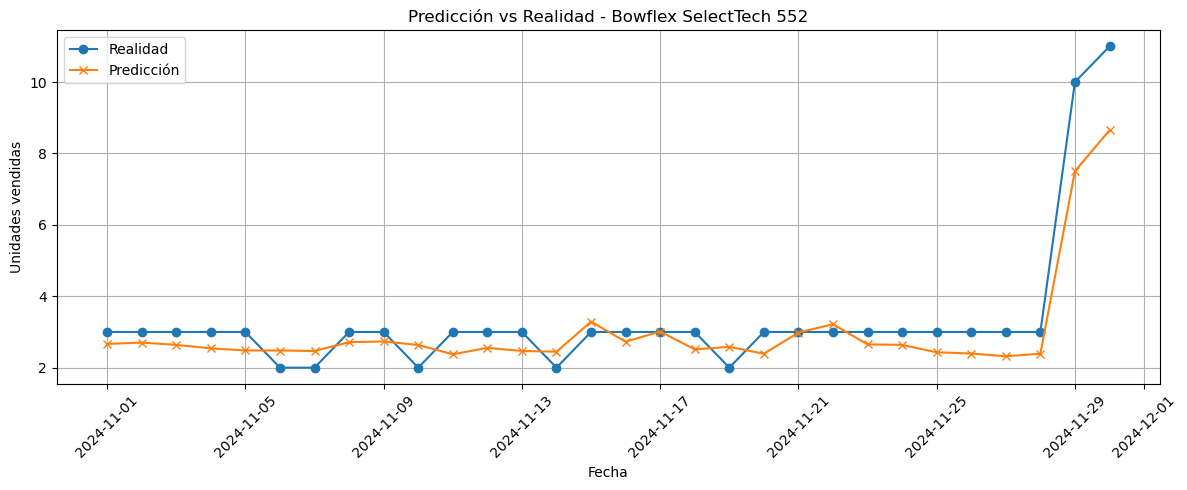

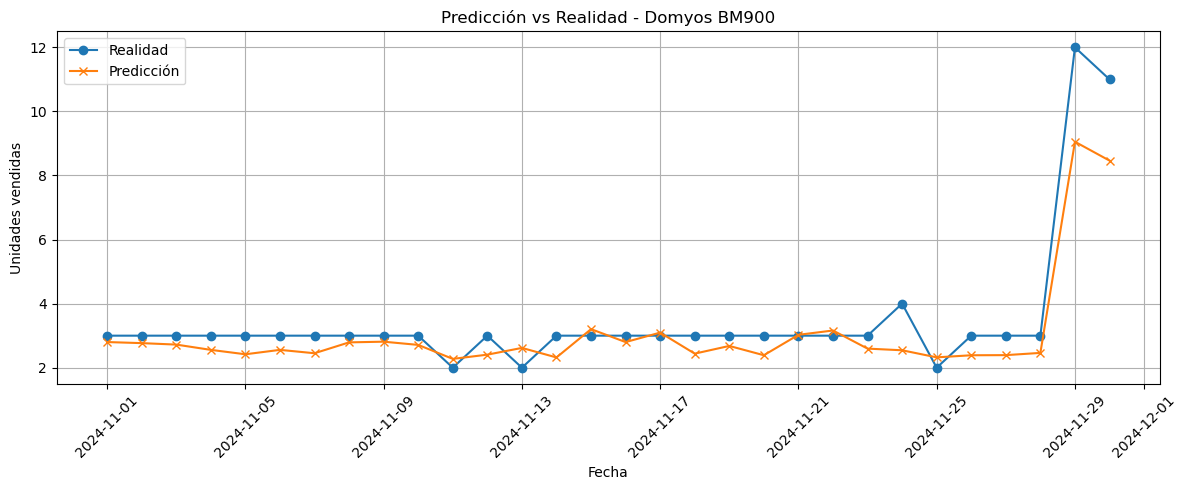

In [82]:
import matplotlib.pyplot as plt

# Filtrar noviembre 2024 y productos estrella
nov_2024 = validation_df[
    (validation_df['fecha'].dt.year == 2024) &
    (validation_df['fecha'].dt.month == 11) &
    (validation_df['es_estrella'] == 1)
].copy()

# Obtener los 7 productos estrella únicos
productos_estrella = nov_2024['nombre'].unique()[:7]

# Variables predictoras
X_cols = [col for col in validation_df.columns if col not in ['fecha', 'ingresos', 'unidades_vendidas'] and validation_df[col].dtype != 'O']

# Graficar para cada producto estrella
for producto in productos_estrella:
    df_prod = nov_2024[nov_2024['nombre'] == producto].copy()
    if df_prod.empty:
        continue
    X_prod = df_prod[X_cols]
    y_real = df_prod['unidades_vendidas']
    y_pred = hgb.predict(X_prod)
    fechas = df_prod['fecha']

    plt.figure(figsize=(12,5))
    plt.plot(fechas, y_real, marker='o', label='Realidad')
    plt.plot(fechas, y_pred, marker='x', label='Predicción')
    plt.title(f'Predicción vs Realidad - {producto}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [83]:
from sklearn.metrics import mean_absolute_error

mae_productos = {}

for producto in productos_estrella:
    df_prod = nov_2024[nov_2024['nombre'] == producto].copy()
    if df_prod.empty:
        continue
    X_prod = df_prod[X_cols]
    y_real = df_prod['unidades_vendidas']
    y_pred = hgb.predict(X_prod)
    mae = mean_absolute_error(y_real, y_pred)
    mae_productos[producto] = mae

for producto, mae in mae_productos.items():
    print(f"MAE para {producto}: {mae:.2f}")

MAE para Manduka PRO Yoga Mat: 1.50
MAE para Trek Marlin 7: 1.28
MAE para Salomon Speedcross 5 GTX: 1.49
MAE para Nike Air Zoom Pegasus 40: 3.45
MAE para Adidas Ultraboost 23: 3.41
MAE para Bowflex SelectTech 552: 0.56
MAE para Domyos BM900: 0.57


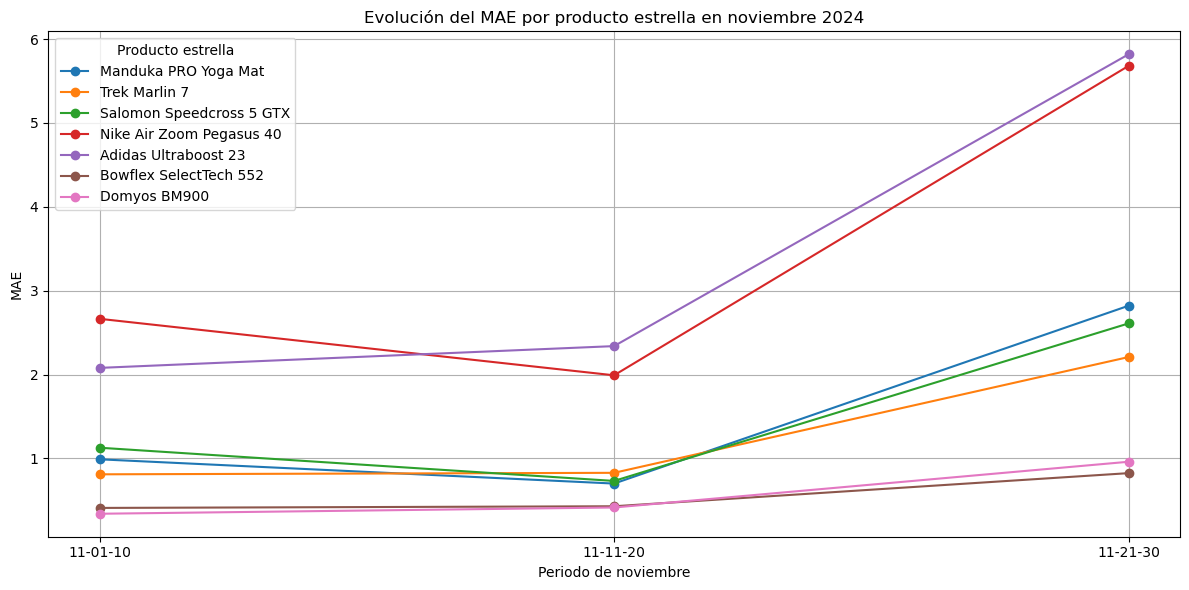

In [84]:
# Analizar la degradación del error por producto estrella y periodo de 10 días

periodos = [
    ('2024-11-01', '2024-11-10'),
    ('2024-11-11', '2024-11-20'),
    ('2024-11-21', '2024-11-30')
]
period_labels = [f"{inicio[5:]}-{fin[8:]}" for inicio, fin in periodos]

# Diccionario: producto -> lista de MAE por periodo
mae_productos_periodo = {producto: [] for producto in productos_estrella}

for producto in productos_estrella:
    df_prod = nov_2024[nov_2024['nombre'] == producto].copy()
    for inicio, fin in periodos:
        df_periodo = df_prod[(df_prod['fecha'] >= pd.to_datetime(inicio)) & (df_prod['fecha'] <= pd.to_datetime(fin))]
        if df_periodo.empty:
            mae_productos_periodo[producto].append(np.nan)
        else:
            X_periodo = df_periodo[X_cols]
            y_real = df_periodo['unidades_vendidas']
            y_pred = hgb.predict(X_periodo)
            mae = mean_absolute_error(y_real, y_pred)
            mae_productos_periodo[producto].append(mae)

# Graficar la evolución del MAE por producto
plt.figure(figsize=(12,6))
for producto, maes in mae_productos_periodo.items():
    plt.plot(period_labels, maes, marker='o', label=producto)
plt.title('Evolución del MAE por producto estrella en noviembre 2024')
plt.xlabel('Periodo de noviembre')
plt.ylabel('MAE')
plt.legend(title='Producto estrella')
plt.grid(True)
plt.tight_layout()
plt.show()

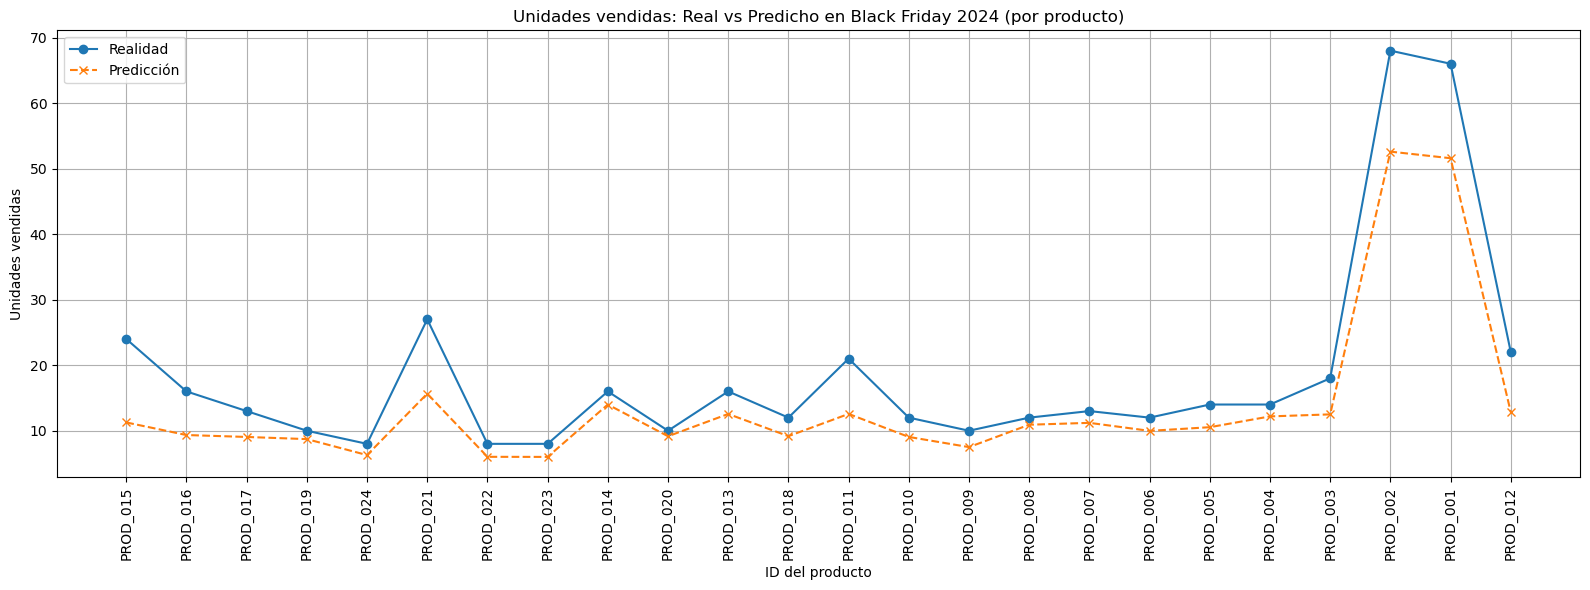

In [85]:
# Analizar Black Friday 2024 para todos los productos

# Identificar la fecha de Black Friday 2024
bf_2024 = pd.to_datetime('2024-11-29')

# Filtrar los datos de ese día
df_bf = validation_df[validation_df['fecha'] == bf_2024].copy()

# Variables predictoras
X_bf = df_bf[X_cols]
y_real_bf = df_bf['unidades_vendidas']
y_pred_bf = hgb.predict(X_bf)

# Preparar para graficar
producto_ids = df_bf['producto_id'].astype(str).values

plt.figure(figsize=(16,6))
plt.plot(producto_ids, y_real_bf, marker='o', linestyle='-', label='Realidad')
plt.plot(producto_ids, y_pred_bf, marker='x', linestyle='--', label='Predicción')
plt.title('Unidades vendidas: Real vs Predicho en Black Friday 2024 (por producto)')
plt.xlabel('ID del producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Modelo final entrenado con todos los datos históricos (2021-2024) usando ventas_df.


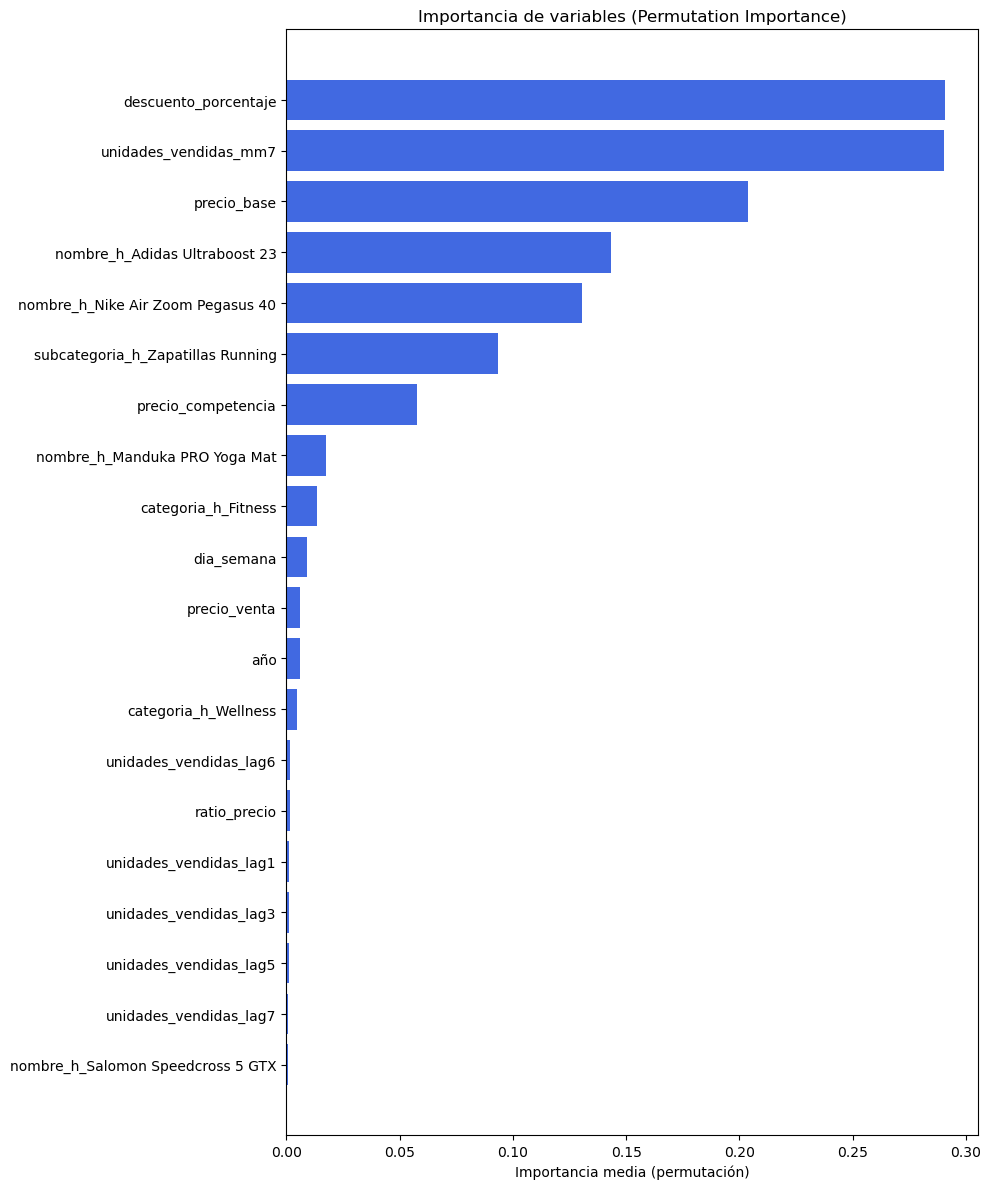

Modelo final guardado en ../models/modelo_final.joblib


In [86]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import joblib
import numpy as np
import os

# Selección de variables predictoras (igual que antes)
excluir = ['fecha', 'ingresos', 'unidades_vendidas']
X_cols_final = [col for col in ventas_df.columns if col not in excluir and ventas_df[col].dtype != 'O']

# Definir X e y para todo el histórico
X_full = ventas_df[X_cols_final]
y_full = ventas_df['unidades_vendidas']

# Entrenar el modelo final
hgb_final = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    early_stopping=True,
    random_state=42
)
hgb_final.fit(X_full, y_full)

print("Modelo final entrenado con todos los datos históricos (2021-2024) usando ventas_df.")

# Calcular la importancia de variables con permutation importance
result = permutation_importance(
    hgb_final, X_full, y_full, n_repeats=10, random_state=42, n_jobs=-1
)

# Extraer importancias y ordenar
importancias = result.importances_mean
indices = np.argsort(importancias)[::-1]
n_vars = min(20, len(X_cols_final))  # Mostrar solo las 20 más importantes si hay muchas

plt.figure(figsize=(10, min(12, n_vars * 0.5 + 2)))
plt.barh(
    [X_cols_final[i] for i in indices[:n_vars]][::-1],
    importancias[indices[:n_vars]][::-1],
    color='royalblue'
)
plt.xlabel('Importancia media (permutación)')
plt.title('Importancia de variables (Permutation Importance)')
plt.tight_layout()
plt.show()

# Guardar el modelo final
os.makedirs('../models', exist_ok=True)
joblib.dump(hgb_final, '../models/modelo_final.joblib')
print("Modelo final guardado en ../models/modelo_final.joblib")